# 1.. How LLM actually Works ( Behind the scenes ) ?


In [ ]:
'''

Hi there 👋 , Welcome to one of the MOST IMPORTANT sections of this OpenAI Codex course !

In this section , we will deep dive into ->> 
    Subagents
    Their types 
    How they work behind the scenes 
    How they get triggered & also a full hands-on demo !




So lets first understand something very basic :

------------------------------------------------------------
🔹 First , lets understand : How does an LLM actually work ?
------------------------------------------------------------

we don’t talk to LLM directly ..

We talk to LLMs via ->> 👉 API Call

[diagram]

There is a wrapper (API) around the LLM ..

Step by step :
   👉 We send our query to API
   👉 API feeds that query into LLM
   👉 LLM gives a response 
   👉 Then we receive that response back via API

Thats how every LLM in this world works …. simple ✅


------------------------------------------------------------
🔹 But here is the BIG problem with LLMs
------------------------------------------------------------

👉 LLMs are STATELESS / MEMORY-LESS .
   They DO NOT have memory of past conversations on their own !


Lets see an example :

API Call 1 :
   You ask  ->> "What is capital of India ?"
   LLM     ->> "Delhi"   ✅


API Call 2 :
   You ask  ->> "What about Germany ?"
   LLM     ->> "What about Germany in what context ?" 🤯

   Why ?
   Because LLMs don’t have memory ..
   They don’t know what you asked in Call 1 !


------------------------------------------------------------
🔹 So how did the developers fix this ?
------------------------------------------------------------

They found a solution :
👉 When you ask a question to LLM ,
   we don't just send the new question -
   we send  ->>   new query + entire previous conversation

So now LLM will have full context of what was discussed before ✅

This is the trick that gives ChatGPT , Gemini & other AI assistants their "memory feel" !


            new query 
                +                   ----->  LLM   (now has full context)
        entire previous conversation


'''

In [ ]:
'''

Let Understand it using a Real World Example : 

------------------------------------------------------------
🔹 Real Example  ->>  Imagine you are a Data Analyst @ YouTube
------------------------------------------------------------

You are using Codex to do your day to day work ..


TURN 1 :
   You say  ->> "With the help of LLM, collect YouTube data for me .."
   Lets say  ->>  this turn consumed roughly ≈ 30K tokens

   ie till Turn 1  ≈  30K tokens spent ✅


TURN 2 :
   Now you say  ->> "Clean this data .."

   But remember - Codex has to send :
        👉  query ( Clean this data )
                   +
        👉  previous Turn 1 conversation ( 30K tokens )
              
   Total sent to LLM  ≈  30K tokens
   LLM does the cleaning & returns new cleaned output  ( imagine 5K tokens )

   ie till Turn 2  ≈  60K – 65K tokens have been spent .. 😳


TURN 3 :
   Now you ask LLM  ->> "Perform Data Analysis on it"

   Again Codex sends  ->>  query + previous conversation [ 65K ]
   LLM responds with EDA output  ( imagine ≈ 20K tokens )

   ie till Turn 3  ≈  130K tokens  +  20K (EDA O/P)
                  =  150K tokens spent !! 🤯


You can clearly see ..
👉 Your context window is getting FILLED so fast ..
👉 And each call is costing you MORE money than the last one ..



------------------------------------------------------------
🔹 So there are 2 MAJOR problems with this approach
------------------------------------------------------------

PROBLEM 1 :  Context Window Overflow
   👉 Every model has a fixed context window ( like 200K , 1M etc )
   👉 If you keep stacking conversation , it fills very fast ..
   👉 Once full -> LLM forgets or breaks ..


PROBLEM 2 :  Lost in the Middle Effect
   👉 LLMs are known to pay MOST attention to the
      START  &  END  of the context .
   👉 They tend to MISS the MIDDLE tokens ..
   👉 So even if your context fits , LLM might "skip" important details
      sitting in the middle ..




------------------------------------------------------------
🔹 So whats the solution ?
------------------------------------------------------------

👉 This is EXACTLY why the idea of  ->>  SUBAGENTS  came into picture 🚀

Subagents solve BOTH of these problems in one shot ..
And thats what we are going to learn next !

'''

# 2.. What is a Subagent & Why to use it ?


In [ ]:
'''

Now we know the problem ..
👉 Context window fills too fast
👉 Lost in the middle effect

Lets see how Subagents solve this beautifully ✨


------------------------------------------------------------
🔹 Definition
------------------------------------------------------------

👉 Subagents are AI Assistants that run inside their OWN
   ISOLATED Context Window ..



   Sub-agent  =  Mini AI agent  +  its own SEPARATE context window


------------------------------------------------------------
🔹 How does it actually work ?
------------------------------------------------------------

[diagram]


                          🟦  Main Agent  🟦
                                 |
              -------------------+-------------------
              |                  |                  |
        Sub-agent 1         Sub-agent 2        Sub-agent 3
        (Data Collector)    (Cleaner)          (Analyser)
        
        (own context win)   (own context win)  (own context win)
        (own SYSTEM PROMPT) (gpt-5.4-mini )
        (own set of SKILLS)
        (own set of TOOLS / MCP servers)
        (diff model access , )
        (gpt-5.5)
        
        

Lets understand step by step :

👉 You give a task to the Main Agent ( the main Codex session )
👉 Main agent says  ->> "Hmm , this part of the task is heavy ,
   let me delegate it to a sub-agent .."
👉 It spins up a Sub-agent  ( for eg : a Data Collection agent )
👉 That Sub-agent has its OWN isolated context window
👉 It does its work independently
👉 Finally , it RETURNS only the result back to the Main agent

So now Main agent gets :
   👉 only the FINAL collected data



------------------------------------------------------------
🔹 And the magic part is …
------------------------------------------------------------

👉 Once the sub-agent's task is done ->>
   its ENTIRE context window is DELETED ✅

Main agent stays clean .
Main context window stays light .
No bloat , no overflow , no lost-in-the-middle ✨


------------------------------------------------------------
🔹 What is the advantage of this ?
------------------------------------------------------------

Q : What is adv. of this ?

Ans : 
   👉 Your context window will NOT fill so fast
   👉 Which automatically results in  ->> 
     👉  LOWER COST 💰 + 👉 better quality responses + 👉 cleaner separation of work
     
     
     
     




'''

# 3.. [Live-Demo] Types of Built-in Subagents  →  
        Built-in Subagents ( default , worker , explorer )


In [ ]:
'''

Hi there 👋 , So far we have learnt :
👉 What a sub-agent is
👉 Why we use them


Now lets talk about :
👉 What TYPES of sub-agents do we have in Codex ?

In general , Codex gives you 2 buckets of sub-agents :

      👉 Built-in  Sub-agents
      👉 Custom    Sub-agents


Lets first deep dive into  ->>  BUILT-IN SUB-AGENTS 🚀


------------------------------------------------------------
🔹 What are Built-in Subagents ?
------------------------------------------------------------

👉 These are sub-agents that Codex ships with & we DON'T have to create it manually !
👉 WE have to ask Codex to call them !

Codex has  ->>  3 built-in sub-agents :

   1)  explorer   ->>  read-heavy codebase exploration
   2)  worker     ->>  execution-focused : implementation , fixes , running tasks
   3)  default    ->>  general-purpose fallback for standard chat / coding



Where do these agents live/stored ?
    Built-in sub-agents (explorer, worker, default) don't exist as files in your home directory.. 
    They live inside Codex's binary/source code.. 



Lets understand each one ✨


------------------------------------------------------------
1)  explorer  Sub-agent
------------------------------------------------------------

👉 You call this sub-agent when you want to do complex Tasks such as "codebase exploration" ..
   Codex does NOT auto-trigger it — you have to explicitly ask :
   
   
   Imagine , u have joined a BIg project in your company & at day-1 , u may not have enough knowledge
   about the Project like:
   What are the coding Standards
   What about the Frameworks , Libraries , APIs
   
   Thats where u can use explorer sub-agent !
   
   


    [VS CODE] : 

    ❌ This will not trigger Explorer Sub-Agent !
          "Explore this part of the codebase .."
          "Tell me what this project does .."
          "Summarise this repo .."


    ✅ This will trigger Explorer Sub-Agent !
            Spawn one explorer Agent per module — explore .agents/ , .codex/ and data/ in parallel and summarise each"
    



   Without sub-agents :   Codex reads them ONE BY ONE  →  It will be slow
                          & context fills up fast on large repos
                          
   With sub-agents    :   3 Agents run SIMULTANEOUSLY  →  It will be faster
                          & each Agent has its own clean context window


        output 
        
        
        
        
        
        
        
[show on PPT]  
------------------------------------------------------------
⚠️  Do Sub-agents use MORE or LESS tokens ?
------------------------------------------------------------
👉 Honest answer  ->>  IT DEPENDS on the task !

CASE 1  ->>  Large codebase  /  multi-turn exploration
   ❌  Single Agent  :
         Turn 1 -> it goes into .agents folder , it spends 30K tokens.. 
         Turn 2 -> it goes into .codex folder , it spends 60K tokens..
         Turn 3 -> it goes into .data folder , it spends sends 120K ..  
         
         context keeps STACKING !
         Total token usage ≈  1M tokens 🤯


   ✅  3 Sub-Agents in parallel :
         Each one starts FRESH  →  no stacking !
         Each uses ≈ 200K  →  
             [ for .agents folder , agent1 uses 200k Tokens]
             [ for .codex folder , agent1 uses 200k Tokens]
             [ for data folder , agent1 uses 200k Tokens]
                  
         Total  ≈  600K tokens only 🎉
         Sub-agents are CHEAPER here !
         
         

CASE 2  ->>  Simple / short task  ( 1-2 turns )
   ✅  Single Agent  :  clean & light
   ❌  Sub-Agents    :  each agent adds its own overhead
                       Sub-agents are MORE EXPENSIVE here !

👉 RULE OF THUMB :
   Complex  +  Parallel  +  Large  =  Sub-agents save tokens ✅
   Simple   +  Short     +  Small  =  Single agent saves tokens ✅
        
        
        
        

'''

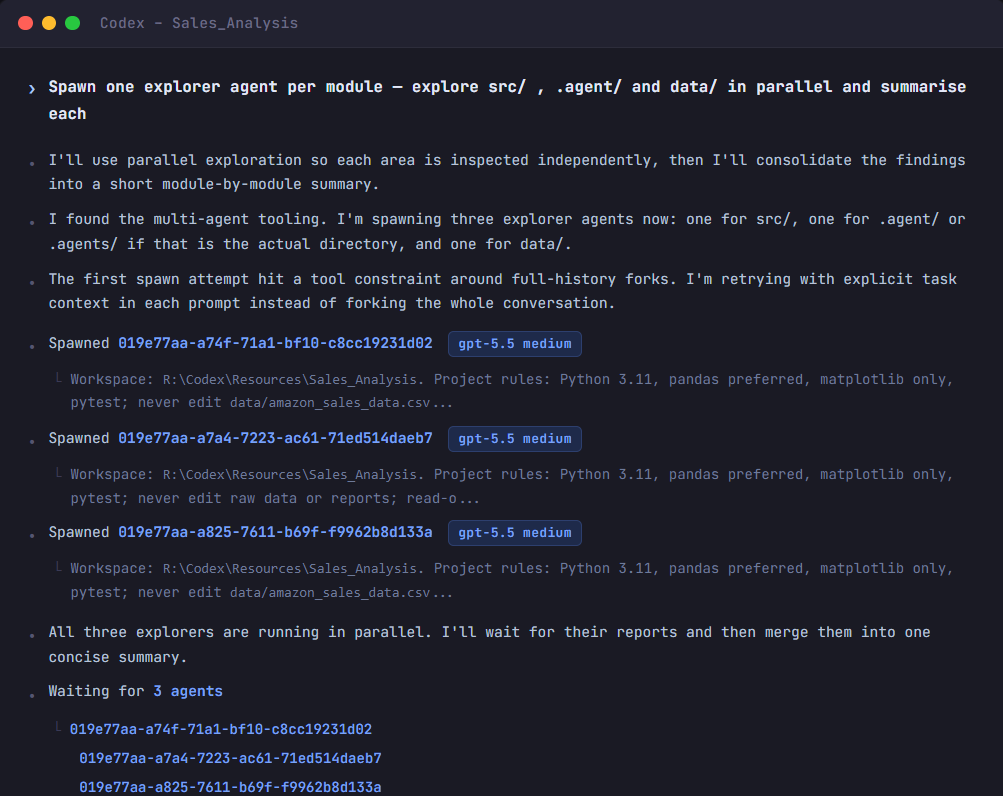

In [ ]:
'''


Here's what this output teaches us —
Line by line breakdown:

› prompt — "per module" + "in parallel" tells Codex to spawn multiple sub-agents, not just one.
- I'll use parallel exploration... — Codex confirms it understood : 3 independent passes, 1 merged summary at the end.
- The first spawn attempt hit a tool constraint... — Codex tried forking full history, hit a limit, auto-retried with explicit context per agent. It recovers gracefully without you doing anything.

- Spawned 019e77aa-a74f... (×3) — 3 separate UUIDs = 3 independent agent threads. Each gets its OWN context window and its OWN model instance.
    └ Workspace: R:\Codex\... (×3) — every explorer is locked to the same workspace but given a DIFFERENT folder scope ( src/ vs .agents/ vs data/ ).

- All three explorers are running in parallel... — this is the KEY moment. All 3 are live simultaneously. Not one by one. True parallelism.
- Waiting for 3 agents └ uuid1  uuid2  uuid3 — parent is blocked on ALL 3 threads at once. It will not consolidate until every explorer reports back.
- Finished waiting └ 019e77aa-a74f...: Completed — first explorer ( src/ ) has returned. Parent logs the result but keeps waiting for the other two.
- The src/ explorer has returned; still waiting on .agents and data/... — Codex narrates partial completion so you always know which threads are done and which are still running.

    - Working 1m 32s • esc to interrupt — live async clock. All 3 explorers are genuinely running in parallel right now. This is what makes sub-agents worth it on large repos.
    Cards : 3× explorer | gpt-5.5 medium | read-only — confirms agent type, model, and sandbox for the entire parallel session.


'''

# 4.. [Demo] : Worker Sub-agent !

In [ ]:
'''

------------------------------------------------------------
2) Worker Sub-agent
------------------------------------------------------------

👉 It is a Execution-focused agent for implementation and fixes ..
👉 Best used when there is REAL WORK to do —

    Like in codebase , if u have 10 files which have Bugs !
    U can actually call 10 worker agent which will work parallelly & fix all the 10 files bugs..


    [VS CODE] : 
    Note : Since we already have a skill as "Analyze Sales-codebase"
            So when I call this worker agent , codex via VS CODE actually trigger skill to fix typos in code !
            
    [ CODEX CLI]
    So lets use same prompt in CODEX CLI , now CODEX CLI will trigger 2 worker agents !
    
    
    
    
    do some typo in test_sales_analysis.py as : import pndas as pd
    do some typo in test_sales_analysis.py as : import pndas as pd
    [CLI] :
    
    '''I am showing u simple version , but u can directly a prompt as 
         "Spawn one worker agent per file — fix all failing tests in test_sales_analysis.py , sales_analysis.py in parallel"
        & Codex will call 2 worker sub-agent for 2 files & Worker agents are able to fix your entire codebase.. '''


    The worker agent will :

        👉 Read relevant files for context
        👉 Implement the feature / fix
        👉 Run the task
        👉 Report back results







'''

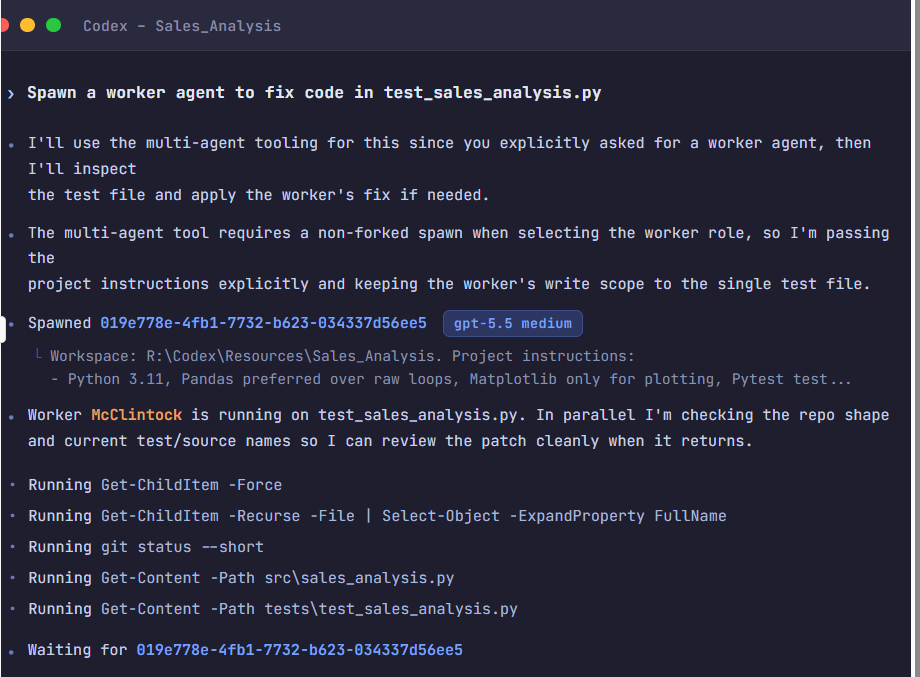

In [ ]:
'''

`Spawned 019e778e-...`
→  Codex assigns a unique ID to every sub-agent the moment it is spawned.

`gpt-5.5 medium` badge
→  The worker runs on this model 

`└ Workspace: R:\Codex\...`
→  The worker's sub-agent scope is locked to this workspace only — it cannot touch anything outside it.



Worker `McClintock`
→  Just a human-readable display nickname — the actual agent type is still  worker.

The 5 `Running` commands
→  The parent orchestrator is working IN PARALLEL while the worker is busy fixing the file.

`Waiting for 019e778e-...`
→  Parent has finished its prep and is now blocked until the worker reports back — same UUID, full circle.






- Running Get-ChildItem -Force — parent(the main Codex session) exploring project structure.
- Running Get-ChildItem -Recurse -File — parent listing all files.
- Running git status --short — parent checking git state.
- Running Get-Content src\sales_analysis.py — parent reading source.
- Running Get-Content tests\test_sales_analysis.py — parent reading
  the same test file the worker is fixing , so it can review the
  patch intelligently when worker returns.


'''

# 5.. [Demo] Default Sub-agent !

In [ ]:
'''

------------------------------------------------------------
3)  default  Sub-agent
------------------------------------------------------------
👉 Whenever YOU need a sub-agent for a MIXED read / write task
   that doesn't cleanly fit explorer or worker  ->>  use the default agent ..

    Used for :
       👉 Generic file reading
       👉 Generic file writing
       👉 Mixed tasks 

    [VS CODE] :
    "Spawn one default agent per region — read the sales dataset,
     calculate top products and revenue trends for North , South ,
     and West regions , and write a summary report for each"


    This task is NOT purely :
       ❌ explore-only
       ❌ a single execution task

    So we explicitly ask Codex to invoke :
       👉 the default sub-agent

------------------------------------------------------------
⚠️  Quick note  —  worker  vs  default  sub-agent
------------------------------------------------------------
👉 Both are execution-capable ..
👉 The key difference  :
      worker   ->>  best for MANY small parallel tasks  ( fix 10 files at once )
      default  ->>  general purpose  ( single / standard tasks )



'''

In [ ]:
'''


 I’ll delegate one default agent per requested region with disjoint report files under reports/. Each agent will read data/amazon_sales_data.csv,
  compute regional product/revenue details, and write only its own summary report.

• Spawned 019e77c2-c82f-75c2-a72f-d6a9bb7cc4a3 (gpt-5.5 medium)
  └ Workspace: `R:\Codex\Resources\Sales_Analysis`. You are not alone in the codebase; do not revert or overwrite edits made by others. Project rules:
  use pandas...

• Spawned 019e77c2-c949-75b3-b1d2-9d6e6d10405e (gpt-5.5 medium)
  └ Workspace: `R:\Codex\Resources\Sales_Analysis`. You are not alone in the codebase; do not revert or overwrite edits made by others. Project rules:
  use pandas...

• Spawned 019e77c2-c9d6-7cd2-8ec7-f3f3622f4a9a (gpt-5.5 medium)
  └ Workspace: `R:\Codex\Resources\Sales_Analysis`. You are not alone in the codebase; do not revert or overwrite edits made by others. Project rules:
  use pandas...

• The three regional agents are running now: North, South, and West each owns a separate Markdown report. I’ll wait for completion, then do a quick
  local check that the expected files exist and contain the requested summaries.

• Waiting for 3 agents
  └ 019e77c2-c82f-75c2-a72f-d6a9bb7cc4a3
    019e77c2-c949-75b3-b1d2-9d6e6d10405e
    019e77c2-c9d6-7cd2-8ec7-f3f3622f4a9a





'''

In [ ]:
'''

------------------------------------------------------------
🔹 Quick Recap : Codex's 3 Built-in Subagents
------------------------------------------------------------

   👉 explorer   ->>  read-only large codebase mapping summarisation
   👉 worker     ->>  implement features , apply fixes , run tasks
   👉 default    ->>  general-purpose fallback for mixed tasks


⚠️  IMPORTANT :
You DO have to explicitly ask Codex to spawn them ..
Codex does NOT auto-pick sub-agents for you ..
YOU tell it which one to spawn — and it handles the rest 🔥


( ⚙️ If a custom agent you create shares a name with a built-in like
  "explorer" , YOUR custom one takes precedence . )



'''

# 6.. [ DEMO ] how the Sub-agent works behind the scenes !


In [ ]:
'''

Hi there 👋 , Time for the FUN part 🎬

Enough theory ..
Lets actually SEE  ->>  how the explorer sub-agent works behind the scenes
on a REAL codebase 🔥


------------------------------------------------------------
🔹 How to actually SEE which Sub-agent Codex is calling
------------------------------------------------------------

👉 The GOOD news : in Codex you don't need any extra tool to watch subagents .
   Subagent activity is surfaced NATIVELY in the Codex CLI & the Codex app ..
   ( IDE-extension visibility is coming soon . )


Step 0 :  Make sure multi-agent workflows are ON
    Current Codex releases enable subagent workflows BY DEFAULT .
    ( If yours doesn't , add  multi_agent = true  under  [features]  in
      ~/.codex/config.toml , or toggle it with  /experimental  in the CLI . )


Step 1 :  Open your Sales project in the Codex CLI
    codex


Step 2 :  Run a prompt that triggers exploration
    Explore this codebase and tell me what this project is about


Step 3 :  Watch your sub-agents LIVE 🔥
    Right inside the CLI / Codex app you will see , in real time :

      👉 the explorer sub-agent appear ( spawned by the main agent )
      👉 its tool calls streaming in — file reads , shell , etc.
      👉 the full agent hierarchy — which subagent was spawned by which parent


Step 4 :  Manage the agent threads with  /agent
    👉 /agent  lets you LIST & SWITCH between active agent threads .
    👉 If an inactive thread asks for approval , press  o  to open it & respond .


Hit Enter & watch the magic 👀


Behind the scenes :
   👉 Codex reads your prompt
   👉 Detects "explore"-type intent
   👉 Automatically TRIGGERS the explorer sub-agent
   👉 The sub-agent crawls files in its OWN isolated context window
   👉 Generates a clean summary
   👉 Returns it to the main agent ✅

👉 You will literally SEE  ->>  "a subagent has been spawned"
👉 along with its name , task , and result 🔥


------------------------------------------------------------
🔹 Same Pattern Works for OTHER Sub-agents Too
------------------------------------------------------------

This SAME technique works for :

   👉 worker Sub-agent
            Trigger it ->>  ask for an implementation / fix task
            Eg :    "Add JWT auth to this app and wire it into the login route .."

   👉 default ( general-purpose ) Sub-agent
            Trigger it ->>  ask for any mixed read/write task
            Eg :    "Read all .md files in docs/ and write a summary into SUMMARY.md"

The CLI / Codex app will show you whichever sub-agent got triggered ✅

'''